# 03 - Incorporacion de anios y benchmark (Ejercicios 5, 6 y 8.3)

Parte 1: validar que 2024, 2025 y 2026 se consultan juntos **con las mismas consultas** (5.6-5.8, 8.3).
Parte 2: analizar `docs/benchmark_results.csv` (6.7-6.9).

In [1]:
import os, sys
from pathlib import Path
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60, "display.width", 180, "display.max_colwidth", 60)

# Dentro del contenedor el proyecto esta en /workspace; fuera, en la carpeta padre de notebooks/.
RAIZ = Path("/workspace") if Path("/workspace/sql").exists() else Path.cwd().parent
sys.path.insert(0, str(RAIZ / "scripts"))
import taxi_common as tc
DATOS = tc.data_dir().as_posix()          # carpeta data/ segun donde se ejecute
from document_queries import abrir

# FUENTE = "parquet": la vista `trips` lee los Parquet de data/raw (normalizados por taxi_common.py).
# FUENTE = "tabla"  : la vista `trips` apunta a la tabla de data/processed/taxi.duckdb (abierta en SOLO LECTURA).
# Las MISMAS consultas sirven para ambas fuentes. Para cambiar: LAB_FUENTE=tabla antes de iniciar Jupyter.
FUENTE = os.environ.get("LAB_FUENTE", "parquet")
con = abrir(FUENTE, str(tc.db_por_defecto()))

def sql(archivo: str) -> pd.DataFrame:
    """Ejecuta un archivo de sql/ y devuelve un DataFrame. La consulta vive en el .sql, no en el notebook."""
    texto = (RAIZ / "sql" / archivo).read_text(encoding="utf-8").replace("/workspace/data", DATOS)
    return con.execute(texto).df()

print("DuckDB", duckdb.__version__, "| fuente:", FUENTE, "| archivos:", len(tc.listar_archivos()))

DuckDB 1.5.5 | fuente: tabla | archivos: 64


## Parte 1 - Consulta conjunta de los anios

## 5.6 Consulta conjunta directamente sobre Parquet

Un comodin cubre todos los anios; no hay que listar archivos.

Consulta: `sql/03_validacion_anios/v00_consulta_conjunta_parquet.sql`

In [2]:
sql("03_validacion_anios/v00_consulta_conjunta_parquet.sql")

,tipo,anio,archivos,registros,primera_recogida,ultima_recogida
0,green,2024,12,660218,2008-12-31 00:00:00,2025-01-01 22:21:15
1,green,2025,12,591375,2008-12-31 15:13:04,2026-01-01 21:09:39
2,green,2026,8,337114,2008-12-31 17:35:31,2026-08-31 23:58:28
3,yellow,2024,12,41169720,2002-12-31 16:46:07,2026-06-26 23:53:12
4,yellow,2025,12,48722602,2007-12-05 18:45:00,2025-12-31 23:59:59
5,yellow,2026,8,29703355,2001-01-01 09:23:58,2026-08-31 23:59:59


### Viajes por archivo (anio y mes)

`sql/03_validacion_anios/v01_viajes_por_anio_mes.sql`

In [3]:
sql("03_validacion_anios/v01_viajes_por_anio_mes.sql")

,anio,mes,yellow,green,total
0,2024,1,2964624,56551,3021175
1,2024,2,3007526,53577,3061103
2,2024,3,3582628,57457,3640085
3,2024,4,3514289,56471,3570760
4,2024,5,3723833,61003,3784836
5,2024,6,3539193,54748,3593941
6,2024,7,3076903,51837,3128740
7,2024,8,2979183,51771,3030954
8,2024,9,3633030,54440,3687470
9,2024,10,3833771,56147,3889918


### Meses faltantes (vacio = sin huecos; un mes final ausente es normal por el atraso de la TLC)

`sql/03_validacion_anios/v02_meses_faltantes.sql`

In [4]:
sql("03_validacion_anios/v02_meses_faltantes.sql")

,taxi_type,mes_faltante


### Fechas fuera del mes de su archivo

`sql/03_validacion_anios/v03_fechas_fuera_de_su_archivo.sql`

In [5]:
sql("03_validacion_anios/v03_fechas_fuera_de_su_archivo.sql")

,anio_archivo,mes_archivo,taxi_type,viajes_fuera_de_mes,fecha_min,fecha_max
0,2024,6,yellow,51,2008-12-31 00:00:00,2026-06-26 23:53:12
1,2024,8,yellow,51,2009-01-01 00:02:52,2024-09-10 12:27:29
2,2024,11,yellow,50,2002-12-31 22:17:43,2024-12-01 22:04:33
3,2024,9,yellow,49,2008-12-31 23:03:46,2024-10-01 21:24:53
4,2024,7,yellow,47,2009-01-01 00:02:24,2024-08-01 23:51:57
5,2026,7,yellow,46,2008-12-30 23:06:00,2026-08-05 20:54:00
6,2025,1,green,43,2024-12-25 23:13:15,2025-02-05 18:46:24
7,2024,10,yellow,40,2009-01-01 00:35:59,2024-11-14 18:30:00
8,2024,12,yellow,34,2008-12-31 23:03:59,2025-03-23 20:42:06
9,2024,9,green,34,2008-12-31 00:00:00,2024-10-01 23:42:50


### Columnas que cambian entre anios

`sql/03_validacion_anios/v04_columnas_por_anio.sql`

In [6]:
sql("03_validacion_anios/v04_columnas_por_anio.sql")

,anio,taxi_type,filas,pct_cbd_congestion_fee,pct_airport_fee,pct_congestion_surcharge,pct_ehail_fee,pct_trip_type
0,2024,green,660218,0.0,0.0,96.3,0.0,96.3
1,2024,yellow,41169720,0.0,90.1,90.1,0.0,0.0
2,2025,green,591375,99.4,0.0,91.6,0.0,91.6
3,2025,yellow,48722602,100.0,76.2,76.2,0.0,0.0
4,2026,green,337114,100.0,0.0,85.5,0.0,85.5
5,2026,yellow,29703355,100.0,74.0,74.0,0.0,0.0


### Metricas por anio

`sql/03_validacion_anios/v05_metricas_por_anio.sql`

In [7]:
sql("03_validacion_anios/v05_metricas_por_anio.sql")

,anio,taxi_type,viajes,dist_prom,tarifa_prom,propina_prom,total_prom,ingresos_millones
0,2024,green,618682,2.97,18.13,2.66,24.21,14.98
1,2024,yellow,39529701,3.44,19.79,3.39,28.63,1131.85
2,2025,green,558644,3.21,17.94,2.73,25.17,14.06
3,2025,yellow,44315588,3.50,19.98,3.06,28.83,1277.67
4,2026,green,316704,3.34,17.09,2.65,25.46,8.06
5,2026,yellow,28364510,3.53,21.16,2.90,30.13,854.66


### Variacion interanual del mismo mes

`sql/03_validacion_anios/v06_comparacion_mismo_mes.sql`

In [8]:
sql("03_validacion_anios/v06_comparacion_mismo_mes.sql")

,taxi_type,anio,mes,viajes,viajes_anio_anterior,variacion_pct
0,green,2024,1,56551,<NA>,NaN
1,green,2025,1,48326,56551,-14.5
2,green,2026,1,40272,48326,-16.7
3,green,2024,2,53577,<NA>,NaN
4,green,2025,2,46621,53577,-13.0
...,...,...,...,...,...,...
59,yellow,2025,10,4428699,3833771,15.5
60,yellow,2024,11,3646369,<NA>,NaN
61,yellow,2025,11,4181444,3646369,14.7
62,yellow,2024,12,3668371,<NA>,NaN


### Control: filas de `trips` vs footer de cada Parquet (debe estar vacio)

`sql/03_validacion_anios/v08_filas_vs_parquet.sql`

In [9]:
sql("03_validacion_anios/v08_filas_vs_parquet.sql")

,source_file,filas_parquet,filas_trips


### Control: `trips` vs `ingest_log` (solo con la tabla; vacio = coincide)

`sql/03_validacion_anios/v07_filas_vs_ingest_log.sql`

In [10]:
sql("03_validacion_anios/v07_filas_vs_ingest_log.sql") if FUENTE == "tabla" else "Requiere LAB_FUENTE=tabla"

,source_file,filas_log,filas_trips


### 5.7 ¿Hubo que modificar las consultas?

No. Las consultas de `sql/01_exploracion` y `sql/02_eda` no mencionan ningún año en la ruta (usan comodines o la vista `trips`), así que al pasar de 2026 a 2024-2026 solo cambió cuántos archivos cubre el comodín. Se ejecutaron sin modificarlas con solo 2026, con los tres años leyendo Parquet y con la tabla: las tres corridas terminaron con 0 fallas (tabla comparativa en `docs/validacion_anios.md`).

## Parte 2 - Benchmark: Parquet directo vs tabla materializada

Requiere `python scripts/benchmark.py`.

In [11]:
res = pd.read_csv(RAIZ / "docs" / "benchmark_results.csv")
res.head()

,escala_meses,archivos,gb_parquet,filas,consulta,fuente,primera_s,mediana_s,minima_s,ejecuciones,resultado_equivalente
0,1,2,0.048,3021175,q01_conteo_total,parquet,0.0528,0.0436,0.0394,5,True
1,1,2,0.048,3021175,q01_conteo_total,tabla,0.4208,0.1908,0.1639,5,True
2,1,2,0.048,3021175,q02_viajes_por_mes_y_tipo,parquet,0.4044,0.2401,0.2230,5,True
3,1,2,0.048,3021175,q02_viajes_por_mes_y_tipo,tabla,3.3007,0.2525,0.2328,5,True
4,1,2,0.048,3021175,q03_tarifas_por_tipo_pago,parquet,0.2603,0.2178,0.1966,5,True


### Razon Parquet / Tabla por consulta y escala (> 1: la tabla fue mas rapida)

In [12]:
t = res.pivot_table(index=["escala_meses", "filas"], columns=["consulta", "fuente"], values="mediana_s")
razon = pd.DataFrame({q: t[(q, "parquet")] / t[(q, "tabla")] for q in sorted({q for q, _ in t.columns})}).round(2)
razon

,,q01_conteo_total,q02_viajes_por_mes_y_tipo,q03_tarifas_por_tipo_pago,q04_top_zonas_recogida,q05_perfil_dia_hora,q06_filtro_selectivo_atipicos,q07_escaneo_multiples_columnas,q08_mediana_y_percentil
escala_meses,filas,,,,,,,,
1,3021175,0.23,0.95,0.72,0.41,0.94,0.63,0.58,1.06
3,9722363,0.57,1.37,1.08,0.93,1.70,0.96,1.00,0.93
6,20671900,0.87,1.77,1.73,1.47,3.04,1.73,1.78,0.85
12,41829938,1.51,2.23,2.65,2.78,4.05,2.57,2.22,1.17
24,91143915,3.42,2.53,3.28,3.67,4.49,3.34,3.47,1.09
32,121184384,476.50,2.99,4.98,13.66,7.64,5.81,5.62,0.95


### Tiempo vs cantidad de datos

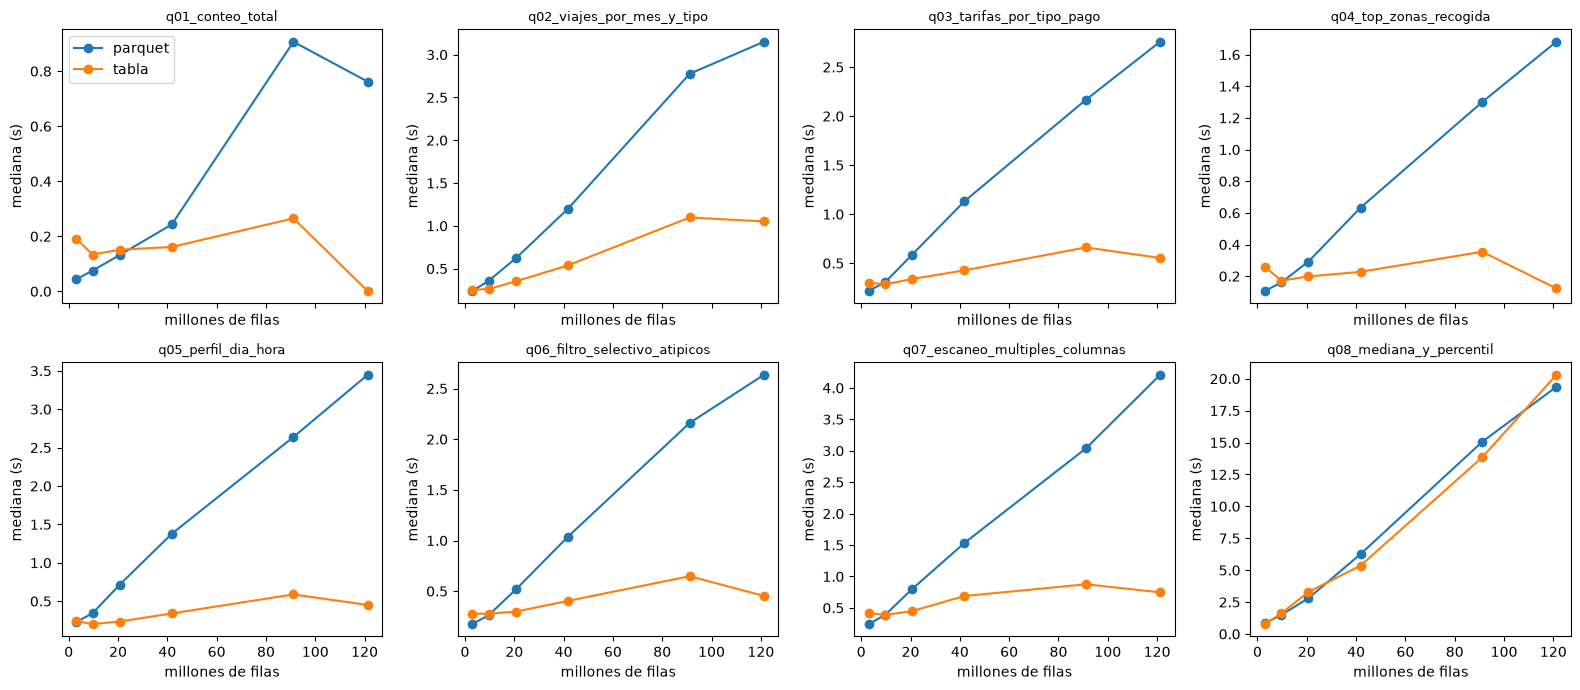

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True)
for ax, (q, g) in zip(axes.flat, res.groupby("consulta")):
    for fuente, gg in g.groupby("fuente"):
        ax.plot(gg["filas"] / 1e6, gg["mediana_s"], marker="o", label=fuente)
    ax.set_title(q, fontsize=9); ax.set_xlabel("millones de filas"); ax.set_ylabel("mediana (s)")
axes.flat[0].legend(); plt.tight_layout(); plt.show()

In [14]:
print("Resultados distintos entre estrategias:", int((~res["resultado_equivalente"]).sum()))

Resultados distintos entre estrategias: 0


El analisis escrito esta en `docs/benchmark_analisis.md`.